# Diagnostics — Comparing Conformal Methods on AirPassengers

This notebook shows how to use `conformal_ts.diagnostics` to compare conformal
prediction methods and pick the best one for a given forecasting task.

Two complementary evaluation modes are demonstrated:

1. **Mode 1 — in-sample (calibration)**: `evaluate_calibration(method)` reuses
   the data the method was calibrated on. Fast and free; tells you whether the
   method achieves its own target coverage on the calibration data. Coverage
   estimates here are **optimistic** compared to true out-of-sample.

2. **Mode 2 — out-of-sample (holdout)**: evaluate on data the method never
   saw during calibration. This is the diagnostic that matters for deployment.

We compare three methods on the AirPassengers dataset (144 monthly
observations, 1949–1960) using `AutoETS` as the underlying forecaster:

* **SplitConformal** — offline baseline, fixed quantile threshold.
* **AdaptiveConformalInference (ACI)** — online, drifts `alpha_t` based on
  realized coverage.
* **NonexchangeableConformalPrediction (NexCP)** — weighted quantile favouring
  recent calibration samples.

**One practical knob:** we pass `refit=True` to `cross_validate`. With
`refit=False`, StatsForecast fits the model once on the earliest cutoff and
forecasts up to 100+ months ahead — residuals balloon with distance from
training. With `refit=True`, the model is refit at each cutoff, so calibration
and holdout residuals come from the same generative process.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import AutoETS
from statsforecast.utils import AirPassengersDF

from conformal_ts.adapters.statsforecast import StatsForecastAdapter
from conformal_ts.methods.split import SplitConformal
from conformal_ts.methods.aci import AdaptiveConformalInference
from conformal_ts.methods.nexcp import NonexchangeableConformalPrediction
from conformal_ts.diagnostics import (
    coverage_by_horizon,
    evaluate_calibration,
    marginal_coverage,
    mean_interval_width,
    rolling_coverage,
    winkler_score,
)

/Users/marcopeix/dev/conformal-ts/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data, fit the model, build the adapter

We use the full 144-month series. The adapter wraps a fitted `AutoETS` with
`season_length=12` and exposes the rolling-origin cross-validation we need
below.

In [2]:
HORIZON = 6
FREQ = "ME"
SEASON_LENGTH = 12
ALPHA = 0.1  # 90% prediction intervals

df = AirPassengersDF.copy()
df["unique_id"] = df["unique_id"].astype(str)

sf = StatsForecast(models=[AutoETS(season_length=SEASON_LENGTH)], freq=FREQ)
sf.fit(df)

adapter = StatsForecastAdapter(
    sf=sf,
    train_df=df,
    horizon=HORIZON,
    freq=FREQ,
    model_name="AutoETS",
)

full_panel = adapter._df_to_panel(df, "y")
T = full_panel.shape[1]
print(f"Panel shape: {full_panel.shape} (n_series, T)")
print(f"Target coverage: {1 - ALPHA:.0%}")

Panel shape: (1, 144) (n_series, T)
Target coverage: 90%


## 2. Build calibration + holdout via a single cross-validation pass

Rolling-origin cross-validation produces matched `(prediction, truth)` pairs
at each cutoff. We do it once with enough windows to cover both the
calibration set **and** a disjoint holdout set. Using `refit=True` ensures the
model is refit at each window's cutoff.

With horizon = 6 and step_size = 1, we keep all CV windows in the **last
~3 years of the series** so calibration and holdout sit in the same regime —
AirPassengers grows multiplicatively, and concentrating both blocks late
keeps the residual scale roughly stable across them. We use:

* the **first 24 windows** as the calibration set (oldest), and
* the **last 12 windows** as the holdout (most recent).

Because the holdout windows are *after* every calibration window in time,
evaluation on them mirrors true out-of-sample deployment.

In [3]:
N_TOTAL = 36
N_CAL = 24
N_HOLDOUT = N_TOTAL - N_CAL  # 12

cv_preds, cv_truths = adapter.cross_validate(n_windows=N_TOTAL, step_size=1, refit=True)
print(f"CV predictions: {cv_preds.shape}")
print(f"CV truths:      {cv_truths.shape}")

cal_preds = cv_preds[:, :N_CAL, :]
cal_truths = cv_truths[:, :N_CAL, :]
ho_preds = cv_preds[:, N_CAL:, :]
ho_truths = cv_truths[:, N_CAL:, :]

print(f"Calibration: {cal_preds.shape[1]} windows")
print(f"Holdout:     {ho_preds.shape[1]} windows")

# Sanity check: are calibration and holdout residuals on the same scale?
cal_resid = float(np.abs(cal_truths - cal_preds).mean())
ho_resid = float(np.abs(ho_truths - ho_preds).mean())
print(f"Mean |residual| — calibration: {cal_resid:.2f}, holdout: {ho_resid:.2f}")

# Reconstruct calibration histories (one history per cutoff) so that we can
# pass them via `method.calibrate(histories, truths)`. StatsForecast's CV
# convention: window i (0-indexed) has cutoff T - HORIZON - (N_TOTAL - 1 - i).
cal_histories = []
for i in range(N_CAL):
    cutoff = T - HORIZON - (N_TOTAL - 1 - i)
    cal_histories.append(full_panel[:, :cutoff].copy())
print(
    f"Calibration history lengths: {cal_histories[0].shape[1]} → {cal_histories[-1].shape[1]} months"
)

CV predictions: (1, 36, 6)
CV truths:      (1, 36, 6)
Calibration: 24 windows
Holdout:     12 windows
Mean |residual| — calibration: 25.11, holdout: 30.32
Calibration history lengths: 103 → 126 months


## 3. Calibrate three conformal methods

All three methods share the same calibration data and target `alpha=0.1`. They
differ in how they turn calibration residuals into a threshold:

* **SplitConformal**: empirical `1 - alpha` quantile (one per horizon step).
* **ACI** (`gamma=0.01`): time-varying `alpha_t`, nudged toward the target each
  update step. We use a small learning rate because AirPassengers' residual
  scale is mildly non-stationary — a large `gamma` would over-react to a
  single miss and drive `alpha_t` outside `[0, 1]`.
* **NexCP** (`rho=0.97`): weighted quantile where weight decays exponentially
  with age — recent calibration samples count more.

In [4]:
split = SplitConformal(adapter, alpha=ALPHA)
split.calibrate(cal_histories, cal_truths)

aci = AdaptiveConformalInference(adapter, alpha=ALPHA, gamma=0.01)
aci.calibrate(cal_histories, cal_truths)

nexcp = NonexchangeableConformalPrediction(adapter, alpha=ALPHA, rho=0.97)
nexcp.calibrate(cal_histories, cal_truths)

methods = {
    "SplitConformal": split,
    "ACI": aci,
    "NexCP": nexcp,
}

for name, m in methods.items():
    print(f"{name}: calibrated on {m.n_calibration_samples_} windows")

SplitConformal: calibrated on 24 windows
ACI: calibrated on 24 windows
NexCP: calibrated on 24 windows


## 4. Mode 1 — in-sample diagnostics via `evaluate_calibration`

`evaluate_calibration` reconstructs the intervals that each method would have
produced on its own calibration data, then computes coverage and interval
quality. No fresh data is needed.

The `method_name` field is suffixed with `(calibration)` to make the data
source clear when reports get printed.

In [5]:
reports_cal = {name: evaluate_calibration(m) for name, m in methods.items()}

for name, report in reports_cal.items():
    print(report.summary())
    print()

Report — SplitConformal (calibration)
  target coverage: 0.900
  marginal coverage: 0.958
  coverage by horizon: [0.958, 0.958, 0.958, 0.958, 0.958, 0.958]
  mean width: 133.272
  mean Winkler score: 137.517
  n_holdout_samples: 24

Report — AdaptiveConformalInference (calibration)
  target coverage: 0.900
  marginal coverage: 0.924
  coverage by horizon: [0.917, 0.917, 0.917, 0.917, 0.917, 0.958]
  mean width: 133.792
  mean Winkler score: 137.863
  n_holdout_samples: 24
  n_observations: 24
  alpha_t drift: max -0.036, min -0.066

Report — NonexchangeableConformalPrediction (calibration)
  target coverage: 0.900
  marginal coverage: 1.000
  coverage by horizon: [1.000, 1.000, 1.000, 1.000, 1.000, 1.000]
  mean width: 143.460
  mean Winkler score: 143.460
  n_holdout_samples: 24
  n_observations: 24
  effective sample size: 23.0



## 5. Mode 2 — out-of-sample diagnostics on the holdout

For online methods (ACI, NexCP), we walk through the holdout windows one at a
time. At each step:

1. Use `_intervals_from_predictions` to apply the **current** fitted state to
   the next holdout prediction.
2. Call `method.update(prediction, truth)` to roll the state forward —
   exactly what a deployed online method would do.

For `SplitConformal` (offline), `update` is a no-op so the same loop works
uniformly across the three methods. We collect the holdout intervals into a
`(n_series, N_HOLDOUT, horizon, 2)` array and run the Layer 1 diagnostics on
it directly.

In [6]:
def run_holdout(method, ho_preds, ho_truths):
    """Walk a calibrated method through the holdout, returning intervals.

    Parameters
    ----------
    method : ConformalMethod
    ho_preds : NDArray, shape (n_series, n_holdout, horizon)
    ho_truths : NDArray, shape (n_series, n_holdout, horizon)

    Returns
    -------
    intervals : NDArray, shape (n_series, n_holdout, horizon, 2)
    """
    n_series, n_holdout, horizon = ho_preds.shape
    pieces = []
    for k in range(n_holdout):
        pred_k = ho_preds[:, k : k + 1, :]
        truth_k = ho_truths[:, k : k + 1, :]
        interval_k = method._intervals_from_predictions(pred_k)
        pieces.append(interval_k)
        # No-op for offline methods (SplitConformal.IS_ONLINE = False).
        if method.IS_ONLINE:
            method.update(pred_k, truth_k)
    return np.concatenate(pieces, axis=1)


ho_intervals = {name: run_holdout(m, ho_preds, ho_truths) for name, m in methods.items()}

summary_rows = []
for name, intervals in ho_intervals.items():
    cov = marginal_coverage(intervals, ho_truths)
    width = float(mean_interval_width(intervals).mean())
    winkler = float(winkler_score(intervals, ho_truths, ALPHA).mean())
    summary_rows.append(
        {
            "method": name,
            "holdout_coverage": cov,
            "target": 1 - ALPHA,
            "mean_width": width,
            "mean_winkler": winkler,
        }
    )
pd.DataFrame(summary_rows).round(3)

,method,holdout_coverage,target,mean_width,mean_winkler
0,SplitConformal,0.917,0.9,133.272,145.854
1,ACI,0.917,0.9,131.422,145.106
2,NexCP,0.931,0.9,135.232,147.448


## 6. Mode 1 vs Mode 2 — does in-sample agree with out-of-sample?

Compare the marginal coverage from each mode side by side. Big gaps between
the two columns are a warning sign: the in-sample report is over-optimistic,
and you shouldn't trust it as a deployment signal.

In [7]:
rows = []
for name in methods:
    cov_cal = reports_cal[name].marginal_coverage
    cov_ho = marginal_coverage(ho_intervals[name], ho_truths)
    rows.append(
        {
            "method": name,
            "target": 1 - ALPHA,
            "mode1_in_sample": cov_cal,
            "mode2_holdout": cov_ho,
            "gap": cov_cal - cov_ho,
        }
    )
comparison = pd.DataFrame(rows).round(3)
comparison

,method,target,mode1_in_sample,mode2_holdout,gap
0,SplitConformal,0.9,0.958,0.917,0.042
1,ACI,0.9,0.924,0.917,0.007
2,NexCP,0.9,1.000,0.931,0.069


## 7. Coverage by horizon — where does each method break?

Marginal coverage can hide horizon-specific failures. Plotting coverage at
each step of the 6-month horizon shows whether intervals degrade at longer
lead times — a common pattern in seasonal time-series forecasting.

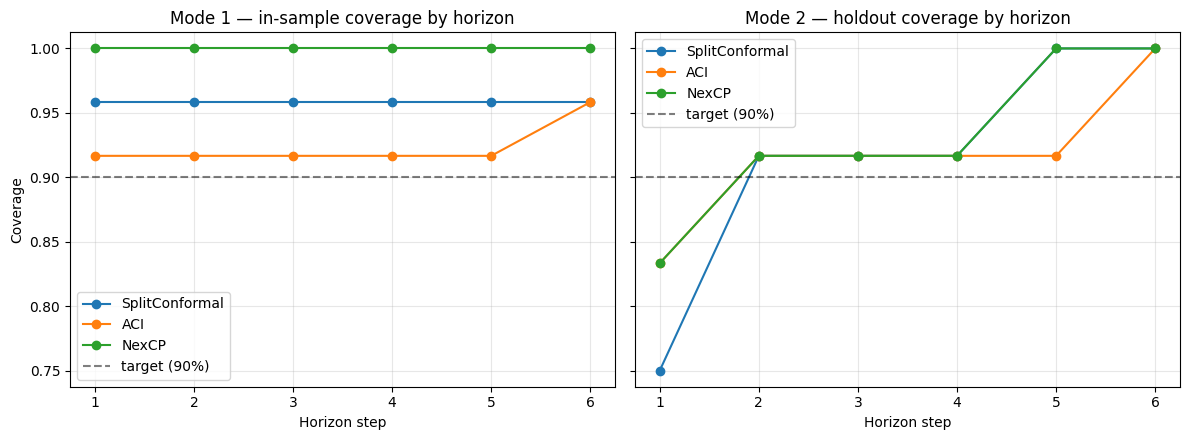

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
horizons = np.arange(1, HORIZON + 1)

for name in methods:
    axes[0].plot(
        horizons,
        reports_cal[name].coverage_by_horizon,
        marker="o",
        label=name,
    )
axes[0].axhline(1 - ALPHA, color="k", linestyle="--", alpha=0.5, label=f"target ({1 - ALPHA:.0%})")
axes[0].set_title("Mode 1 — in-sample coverage by horizon")
axes[0].set_xlabel("Horizon step")
axes[0].set_ylabel("Coverage")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for name, intervals in ho_intervals.items():
    axes[1].plot(
        horizons,
        coverage_by_horizon(intervals, ho_truths),
        marker="o",
        label=name,
    )
axes[1].axhline(1 - ALPHA, color="k", linestyle="--", alpha=0.5, label=f"target ({1 - ALPHA:.0%})")
axes[1].set_title("Mode 2 — holdout coverage by horizon")
axes[1].set_xlabel("Horizon step")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 8. Interval width by horizon

Coverage isn't free — a method achieving the target by widening intervals
indiscriminately isn't actually informative. Comparing **mean widths** at the
same nominal level lets us judge which method is most efficient.

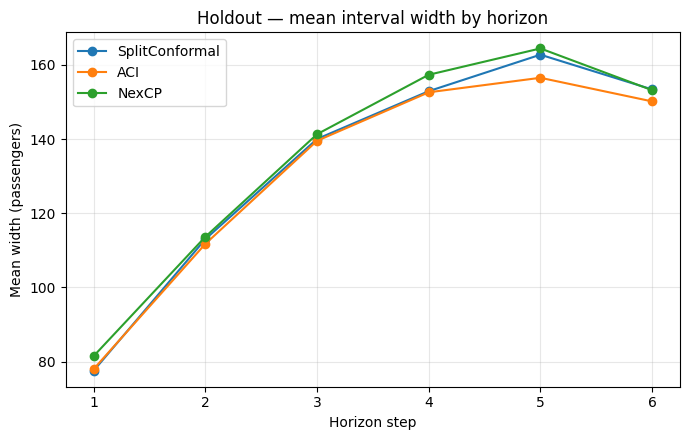

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for name, intervals in ho_intervals.items():
    width_per_h = mean_interval_width(intervals).mean(axis=0)  # (horizon,)
    ax.plot(horizons, width_per_h, marker="o", label=name)
ax.set_title("Holdout — mean interval width by horizon")
ax.set_xlabel("Horizon step")
ax.set_ylabel("Mean width (passengers)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 9. Rolling coverage through the holdout

For online methods, the key question is whether coverage **adapts** as the
holdout progresses. `rolling_coverage` averages the cell-wise coverage
indicator over a sliding window of holdout samples; a stable line near the
target means the method tracks well.

We average over horizon for clarity, leaving one curve per method.

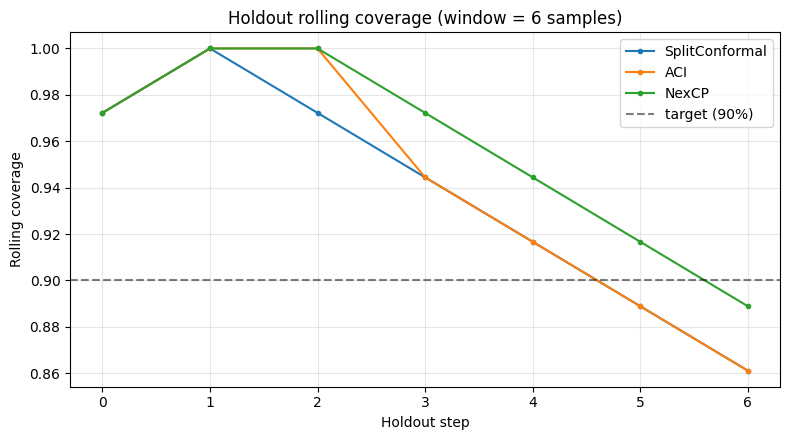

In [10]:
WINDOW = 6
fig, ax = plt.subplots(figsize=(8, 4.5))
for name, intervals in ho_intervals.items():
    # shape (n_series, n_holdout - WINDOW + 1, horizon) → average over series + horizon
    rc = rolling_coverage(intervals, ho_truths, window=WINDOW)
    ax.plot(np.arange(rc.shape[1]), rc.mean(axis=(0, 2)), marker=".", label=name)
ax.axhline(1 - ALPHA, color="k", linestyle="--", alpha=0.5, label=f"target ({1 - ALPHA:.0%})")
ax.set_title(f"Holdout rolling coverage (window = {WINDOW} samples)")
ax.set_xlabel("Holdout step")
ax.set_ylabel("Rolling coverage")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 10. Method-specific state — how did ACI adapt?

Layer 2 diagnostics expose the internals of each method. For ACI, the most
informative quantity is `alpha_t - alpha`, the drift from the target
miscoverage rate. Cells where this is far from zero are where ACI most
actively adapted.

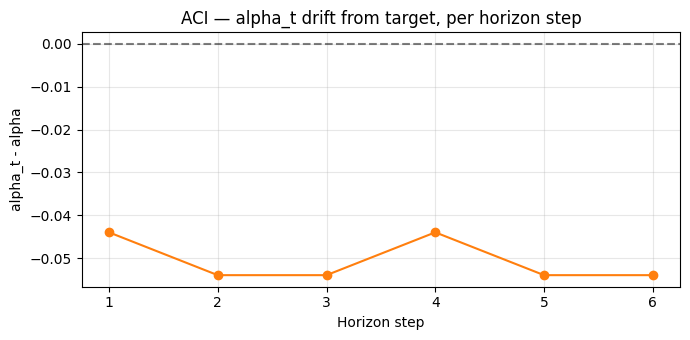

Total ACI observations (calibration + holdout updates): 36
max |drift|: 0.0540


In [11]:
drift = aci.alpha_t_ - aci.alpha  # shape (n_series, horizon)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(horizons, drift[0], marker="o", color="tab:orange")
ax.axhline(0, color="k", linestyle="--", alpha=0.5)
ax.set_title("ACI — alpha_t drift from target, per horizon step")
ax.set_xlabel("Horizon step")
ax.set_ylabel("alpha_t - alpha")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Total ACI observations (calibration + holdout updates): {aci.n_observations_}")
print(f"max |drift|: {np.abs(drift).max():.4f}")

## 11. Picking the best method

Look at the holdout comparison: pick the method that hits the target coverage
with the **smallest mean width** (or, equivalently, the lowest Winkler score —
Winkler bundles both metrics into one number).

A few practical heuristics:

* If all three methods deliver similar holdout coverage and width, pick the
  simplest: `SplitConformal`. There's no benefit to online machinery if it
  doesn't move the needle.
* If `SplitConformal` undercovers and an online method recovers the target,
  the data has non-stationarity that needs adaptation.
* If `ACI` over-corrects (wide intervals, coverage well above target), try a
  smaller `gamma` or fall back to `NexCP`.

Whatever you pick, **report Mode 2 numbers**, not Mode 1. In-sample diagnostics
are good for catching outright bugs (e.g. coverage well below target on the
calibration data) but they overstate how the method will behave in production.

In [12]:
final = pd.DataFrame(summary_rows).set_index("method").round(3)
final["coverage_gap"] = (final["holdout_coverage"] - final["target"]).round(3)
final

,holdout_coverage,target,mean_width,mean_winkler,coverage_gap
method,,,,,
SplitConformal,0.917,0.9,133.272,145.854,0.017
ACI,0.917,0.9,131.422,145.106,0.017
NexCP,0.931,0.9,135.232,147.448,0.031
